# Bayesian Estimation of Temperature-Related and Day-to-Day Effects in PV Performance

## 1. Problem formulation

### Problem statement

Photovoltaic power output is mainly driven by solar irradiance, but the same irradiance level can still lead to different power output depending on module temperature, weather conditions, measurement noise and day-specific operating conditions. Higher module temperature is expected to reduce PV performance mainly because the open-circuit voltage of a solar cell decreases as temperature increases. Although the short-circuit current can increase slightly, this effect is usually not sufficient to compensate for the voltage loss, so the maximum power decreases. [6]

The main research question is:

**Can Bayesian modelling of normalized PV performance be used to estimate temperature-related losses and detect day-specific deviations in system operation?**

Raw DC power is not modelled directly, because it is dominated by irradiance. Instead, the response variable is based on the PV performance ratio concept. In standard PV monitoring, performance ratio is commonly defined as the ratio of final yield to reference yield, where the reference yield is based on plane-of-array irradiation normalized by the reference irradiance $G_{STC}=1000~\mathrm{W/m^2}$. In this project, an interval-based DC version of this idea is used [1]:


$PR_i =
\frac{P_{DC,i}}
{P_{rated} \cdot \frac{G_{POA,i}}{G_{STC}}},
\qquad
G_{STC}=1000~\mathrm{W/m^2}.
$ 

where:

- $P_{DC,i}$ is measured DC power,
- $P_{rated}$ is rated DC power of the PV array,
- $G_{POA,i}$ is plane-of-array irradiance,
- $G_{STC}$ is the reference irradiance.

In this project, $P_{rated}$ was set to $271~\mathrm{kW}$, because the analysed NIST Ground Mount Array consists of 1152 monocrystalline silicon modules with a rated power of $235~\mathrm{W}$ each. [3] This gives:

$P_{rated} = 1152 \cdot 235~\mathrm{W} = 270720~\mathrm{W} \approx 271~\mathrm{kW}.$

The response used in the Bayesian models is:

$y_i = \log(PR_i)$.

The logarithmic transformation is used because \(PR_i>0\), and regression effects on the log scale can be interpreted approximately as relative or percentage changes in performance.

### Objectives and use cases

The aim of this project is to model normalized PV performance and use it for basic performance diagnostics. The response variable is based on performance ratio rather than raw DC power, because raw power is dominated by irradiance. This allows the analysis to focus on secondary effects such as temperature-related losses and day-to-day deviations.

The first objective is to estimate the temperature-loss coefficient of the PV array. The model should quantify how much performance ratio changes with increasing module temperature and provide posterior uncertainty for this effect. The estimated coefficient can then be compared with values expected from PV literature and standard PV performance models.

The second objective is to quantify day-to-day variability in temperature-corrected PV performance. Even after accounting for irradiance and module temperature, some days may show systematic underperformance or overperformance. Such deviations may be related to atmospheric conditions, irradiance measurement mismatch, temporary shading, soiling-like effects, sensor issues, inverter behaviour or other unmodelled operating conditions.

The practical use case is PV monitoring and diagnostics. The model should help estimate expected temperature-related losses, identify days with unusual performance, and quantify the typical scale of daily deviations. In this sense, the analysis is not only predictive, but also diagnostic: it separates expected thermal effects from additional day-level performance changes.

### Data source and description

The data come from the **NIST Campus Photovoltaic Arrays and Weather Station Data Sets**. The analysis uses the **Ground Mount Array** at the NIST PV testbed in Gaithersburg, Maryland, USA. The Ground Mount Array contains 1152 modules and has a rated DC output of approximately  $271~\mathrm{kW}$.

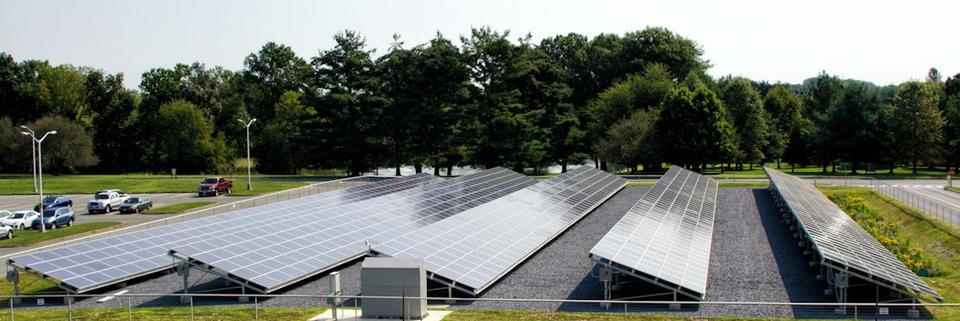
*Figure 1: NIST Ground Mount PV array used in this project.*

The raw files contain one-minute averaged measurements from the PV array and associated weather sensors. This project uses the summer period of 2016: June, July and August.

The variables used in the analysis are:

| Raw column | Meaning | Used as |
|---|---|---|
| `TIMESTAMP` | measurement timestamp | time variable |
| `InvPDC_kW_Avg` | average inverter DC power | $P_{DC}$ |
| `SEWSPOAIrrad_Wm2_Avg` | plane-of-array irradiance | $G_{POA}$ |
| `SEWSModuleTemp_C_Avg` | PV module temperature | $T_m$ |

The key derived variables are:

| Derived column | Meaning |
|---|---|
| `expected_P_DC_kW` | irradiance-scaled expected DC power |
| `PR` | interval-based DC performance ratio |
| `logPR` | response variable for Bayesian modelling |
| `x_T` | min-max normalized module temperature |
| `T_range_C` | module temperature range used to convert the normalized temperature coefficient back to an effect per ($10^\circ C$) |
| `day_id` | consecutive day index used by the hierarchical daily-offset model |

### Modelling intuition

After defining $log(PR)$ as the response variable, the analysis focuses on two sources of variation in normalized PV performance.

The first source is module temperature:

```text
module temperature ───→ modelled log(PR)
```

Higher module temperature is expected to reduce PV performance, because increasing cell temperature mainly lowers the open-circuit voltage of the solar cells, which reduces the maximum power point.

The second source is day-to-day variation that remains after accounting for temperature:

```text
module temperature ───────────────┐
                                  ├──→ modelled log(PR)
day-specific deviation ───────────┘
```

These day-specific deviations are not treated as a direct measurement of one physical mechanism. Instead, they represent systematic daily underperformance or overperformance that may be related to residual weather effects, irradiance measurement mismatch, temporary shading, soiling-like losses, sensor issues, inverter behaviour, or other unmodelled operating conditions.


## 2. Data selection and preprocessing

The preprocessing was kept simple and focused on obtaining a reliable modelling dataset for pointwise performance-ratio analysis.

The following steps were applied:

1. **Array and period selection**
   Only the NIST Ground Mount Array was used. The analysed period was June-August 2016.

2. **Performance-ratio calculation**
   The DC performance ratio was then calculated from the rated array power and plane-of-array irradiance as:

   $PR_i=\frac{P_{DC,i}}{P_{rated}\frac{G_{POA,i}}{G_{STC}}}.$

3. **Daytime filtering**  
   Only measurements between 09:00 and 16:00 were retained. This avoids low-irradiance periods near sunrise and sunset, where the denominator of the pointwise $PR$ calculation can be close to zero. In such cases, $PR$ can be strongly affected by power measurement noise and becomes poorly informative for modelling.

4. **Five-minute subsampling**
   The raw data are one-minute averages. To reduce dataset size and limit strong autocorrelation, only timestamps at five-minute intervals were retained.

5. **Temperature normalization**
   Module temperature was min-max normalized to the interval $[0,1]$:

   $x_{T,i}=\frac{T_{m,i}-T_{\min}}{T_{\max}-T_{\min}}.$

   The Stan models use this normalized predictor, while the temperature effect is reported as the performance change per $10^\circ C$.


In [3]:
df.describe()

,timestamp,month,hour,logPR,PR,x_T,z_wind,T_module_C,wind_ms,G_POA_Wm2,P_DC_kW,expected_P_DC_kW,power_ratio
count,3558,3558.000000,3558.000000,3558.000000,3558.000000,3558.000000,3.558000e+03,3558.000000,3558.000000,3558.000000,3558.000000,3558.000000,3558.000000
mean,2016-08-01 13:39:20.978077,7.420180,12.455153,-0.115657,0.891201,2.989113,7.189303e-17,54.891127,1.810391,949.845756,229.165402,257.408200,0.891201
min,2016-06-01 11:01:00,6.000000,11.000000,-0.287484,0.750149,0.356000,-1.972071e+00,28.560000,0.135000,702.500000,152.900000,190.377500,0.750149
25%,2016-06-20 12:52:15,6.000000,11.700000,-0.134152,0.874457,2.670000,-7.043546e-01,51.700000,1.212000,906.000000,220.600000,245.526000,0.874457
50%,2016-08-15 11:57:30,8.000000,12.433333,-0.118366,0.888371,3.066000,-8.638680e-02,55.660000,1.737000,948.000000,228.200000,256.908000,0.888371
75%,2016-08-24 13:19:45,8.000000,13.216667,-0.095295,0.909105,3.408750,5.468831e-01,59.087500,2.275000,995.000000,237.400000,269.645000,0.909105
max,2016-08-31 13:46:00,8.000000,14.000000,0.041162,1.042021,4.168000,6.932550e+00,66.680000,7.700000,1232.000000,282.800000,333.872000,1.042021
std,NaN,0.887997,0.868469,0.030799,0.027239,0.572175,1.000000e+00,5.721753,0.849559,66.786167,14.276274,18.099051,0.027239


## 3. Exploratory data analysis

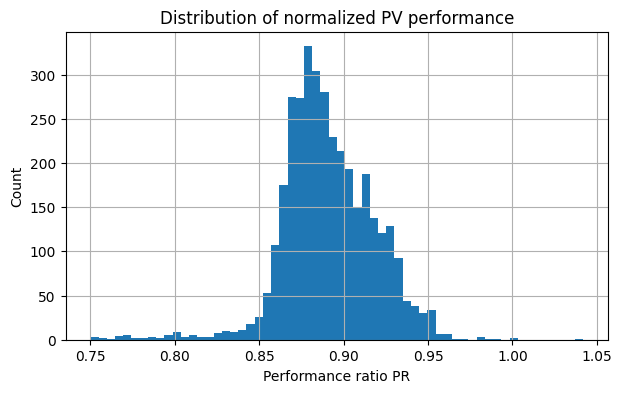

In [4]:
plt.figure(figsize=(7, 4))
plt.hist(df["PR"], bins=60)
plt.xlabel("Performance ratio PR")
plt.ylabel("Count")
plt.title("Distribution of normalized PV performance")
plt.grid(True)
plt.show()

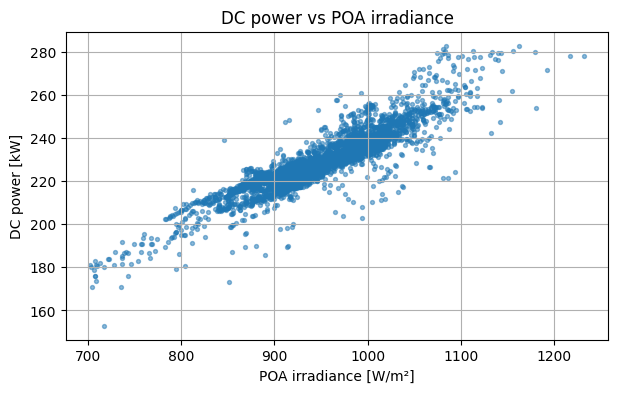

In [5]:
plt.figure(figsize=(7, 4))
plt.scatter(df["G_POA_Wm2"], df["P_DC_kW"], s=8, alpha=0.5)
plt.xlabel("POA irradiance [W/m²]")
plt.ylabel("DC power [kW]")
plt.title("DC power vs POA irradiance")
plt.grid(True)
plt.show()

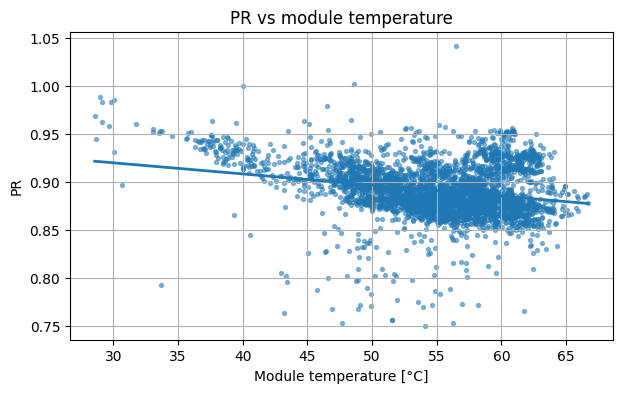

EDA linear slope: -0.00116 PR / °C


In [6]:
plt.figure(figsize=(7, 4))
plt.scatter(df["T_module_C"], df["PR"], s=8, alpha=0.5)

# Simple visual linear trend, only for EDA.
coef = np.polyfit(df["T_module_C"], df["PR"], 1)
x = np.linspace(df["T_module_C"].min(), df["T_module_C"].max(), 100)
plt.plot(x, coef[0] * x + coef[1], linewidth=2)

plt.xlabel("Module temperature [°C]")
plt.ylabel("PR")
plt.title("PR vs module temperature")
plt.grid(True)
plt.show()

print(f"EDA linear slope: {coef[0]:.5f} PR / °C")

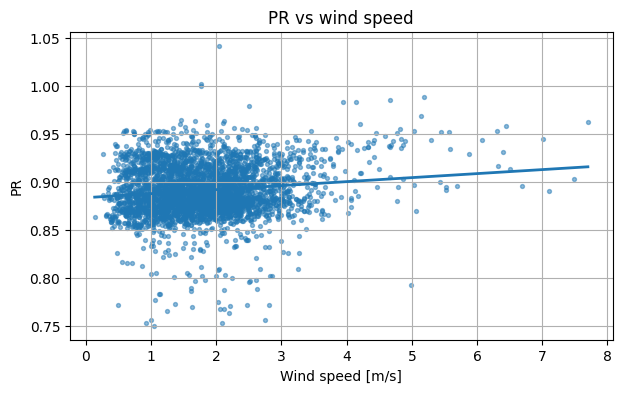

EDA linear slope: 0.00418 PR / (m/s)


In [7]:
plt.figure(figsize=(7, 4))
plt.scatter(df["wind_ms"], df["PR"], s=8, alpha=0.5)

coef = np.polyfit(df["wind_ms"], df["PR"], 1)
x = np.linspace(df["wind_ms"].min(), df["wind_ms"].max(), 100)
plt.plot(x, coef[0] * x + coef[1], linewidth=2)

plt.xlabel("Wind speed [m/s]")
plt.ylabel("PR")
plt.title("PR vs wind speed")
plt.grid(True)
plt.show()

print(f"EDA linear slope: {coef[0]:.5f} PR / (m/s)")

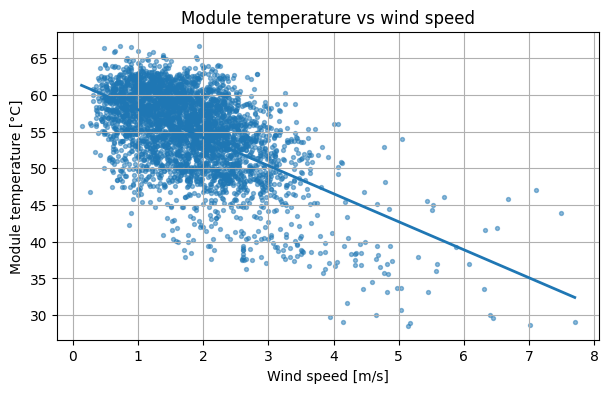

EDA linear slope: -3.81701 °C / (m/s)


In [8]:
plt.figure(figsize=(7, 4))
plt.scatter(df["wind_ms"], df["T_module_C"], s=8, alpha=0.5)

coef = np.polyfit(df["wind_ms"], df["T_module_C"], 1)
x = np.linspace(df["wind_ms"].min(), df["wind_ms"].max(), 100)
plt.plot(x, coef[0] * x + coef[1], linewidth=2)

plt.xlabel("Wind speed [m/s]")
plt.ylabel("Module temperature [°C]")
plt.title("Module temperature vs wind speed")
plt.grid(True)
plt.show()

print(f"EDA linear slope: {coef[0]:.5f} °C / (m/s)")

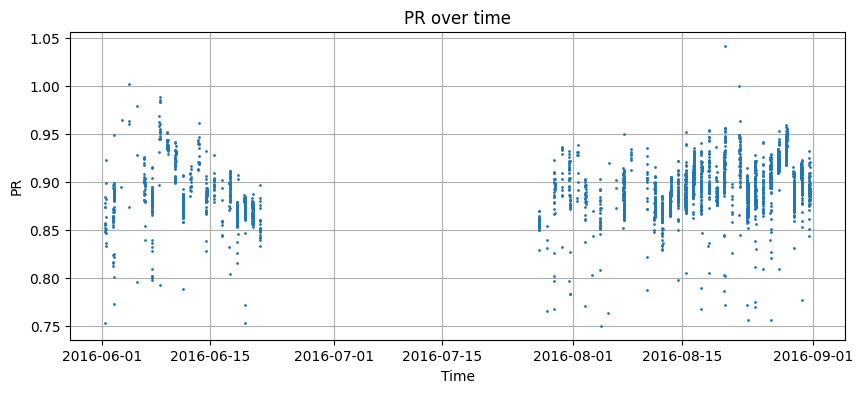

In [9]:
if "timestamp" in df.columns:
    plt.figure(figsize=(10, 4))
    plt.plot(df["timestamp"], df["PR"], ".", markersize=2)
    plt.xlabel("Time")
    plt.ylabel("PR")
    plt.title("PR over time")
    plt.grid(True)
    plt.show()

C:\Users\Maria\AppData\Local\Temp\ipykernel_23364\3424788920.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_month, labels=months)


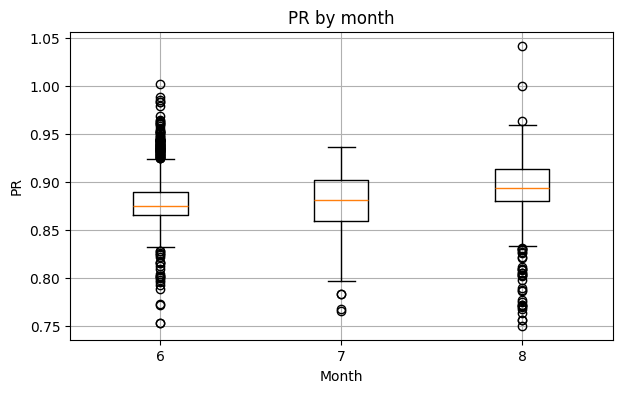

month
6     969
7     125
8    2464
dtype: int64


In [10]:
if "month" in df.columns:
    months = sorted(df["month"].unique())
    data_by_month = [df.loc[df["month"] == m, "PR"] for m in months]

    plt.figure(figsize=(7, 4))
    plt.boxplot(data_by_month, labels=months)
    plt.xlabel("Month")
    plt.ylabel("PR")
    plt.title("PR by month")
    plt.grid(True)
    plt.show()

    print(df.groupby("month").size())

## 4. Proposed Bayesian models

Both models use the same response variable:

\[
y_i=\log(PR_i).
\]

A Student-\(t\) likelihood is used:

\[
y_i \sim \mathrm{StudentT}(\nu,\mu_i,\sigma).
\]

The Student-\(t\) likelihood is chosen because PV monitoring data can still contain outliers caused by clouds, temporary shading, sensor noise, inverter behaviour or imperfect irradiance normalization. The Student-\(t\) distribution gives the model heavier tails than a Gaussian likelihood and makes the inference less sensitive to individual unusual observations.

### Model 1: temperature-only model

The first model estimates the average effect of module temperature on normalized PV performance:

\[
y_i \sim \mathrm{StudentT}(\nu,\mu_i,\sigma),
\]

\[
\mu_i = \alpha + \beta_{T,norm}x_{T,i}.
\]

The predictor \(x_T\) is min-max normalized to \([0,1]\). To keep the coefficient physically interpretable, the model defines a separate parameter:

\[
\beta_{T,10C},
\]

which represents the effect on \(\log(PR)\) for a \(10^\circ C\) increase in module temperature. Inside Stan it is converted to the coefficient for the normalized predictor:

\[
\beta_{T,norm}=\beta_{T,10C}\frac{T_{range}}{10}.
\]

The main quantity of interest is:

\[
P(\beta_{T,10C}<0 \mid \mathrm{data}).
\]

If this probability is high, the data support the hypothesis that higher module temperature reduces normalized PV performance.

### Model 2: temperature model with daily offsets

The second model keeps the same temperature effect but adds a latent day-specific offset:

\[
y_i \sim \mathrm{StudentT}(\nu,\mu_i,\sigma),
\]

\[
\mu_i = \alpha + \beta_{T,norm}x_{T,i}+\delta_{day[i]}.
\]

The daily offsets are modelled hierarchically:

\[
\delta_d \sim \mathrm{Normal}(0,\sigma_{day}).
\]

The purpose of Model 2 is to check whether temperature-corrected PV performance is stable from day to day. The daily offsets may capture residual weather effects, irradiance measurement mismatch, soiling-like effects, sensor drift or other unmodelled daily operating conditions.

The key additional parameter is:

\[
\sigma_{day},
\]

which measures the typical day-to-day variability in \(\log(PR)\) after accounting for temperature.

## 5. Prior proposal

The temperature predictor is normalized to \([0,1]\), but the temperature-effect prior is placed on the physically interpretable parameter \(\beta_{T,10C}\), i.e. the effect per \(10^\circ C\).

For Model 1:

\[
\alpha \sim \mathrm{Normal}(\log(0.95),0.25),
\]

\[
\beta_{T,10C} \sim \mathrm{Normal}(0,0.10),
\]

\[
\sigma \sim \mathrm{Normal}^{+}(0,0.08),
\]

\[
\nu \sim \mathrm{Normal}(15,10), \quad 5<\nu<50.
\]

The prior for \(\beta_{T,10C}\) is intentionally weakly informative and centred at zero. It does not force a negative temperature effect, but it keeps the prior predictive distribution in a physically plausible range.

For Model 2, the same priors are used for \(\alpha\), \(\beta_{T,10C}\), \(\sigma\) and \(\nu\), with one additional hierarchical scale parameter:

\[
\sigma_{day} \sim \mathrm{Normal}^{+}(0,0.03).
\]

This prior allows day-to-day deviations but shrinks daily offsets toward zero unless the data support systematic daily differences.

## 6. Summary of modelling plan

The project compares two Bayesian models:

| Model | Formula | Purpose |
|---|---|---|
| Model 1 | \(\log(PR) \sim T_m\) | estimate the average temperature effect |
| Model 2 | \(\log(PR) \sim T_m +\) daily offset | check whether temperature-corrected performance varies between days |

The main expected outputs are:

- posterior distribution of the temperature effect per \(10^\circ C\),
- probability that the temperature effect is negative,
- posterior predictive checks,
- daily offsets and \(\sigma_{day}\) from Model 2,
- comparison of whether Model 2 explains residual day-to-day structure better than Model 1.

## References

[1] PV Performance Modeling Collaborative, Sandia National Laboratories. *Performance Ratio*.  
https://pvpmc.sandia.gov/modeling-guide/5-ac-system-output/pv-performance-metrics/performance-ratio/

[2] National Institute of Standards and Technology. *Photovoltaic Testbeds*.  
https://www.nist.gov/el/beed/heat-transfer-alternative-energy-systems/photovoltaic-testbeds

[3] National Institute of Standards and Technology. *Ground Mount Array*.  
https://www.nist.gov/el/beed/heat-transfer-alternative-energy-systems/photovoltaic-testbeds/ground-mount-array

[4] Boyd, M. T. (2017). *High-Speed Monitoring of Multiple Grid-Connected Photovoltaic Array Configurations and Weather Station Data*. NIST Technical Note 1896.  
https://nvlpubs.nist.gov/nistpubs/TechnicalNotes/NIST.TN.1896.pdf

[5] U.S. Department of Energy / NREL. *Understanding Solar Photovoltaic System Performance*.  
https://www.energy.gov/sites/default/files/2022-02/understanding-solar-photo-voltaic-system-performance.pdf

[6] PV Education. Effect of Temperature.  
https://www.pveducation.org/pvcdrom/solar-cell-operation/effect-of-temperature